**Name - Arihant Gupta**
<br>
**Enrolment - E23CSEU0055**
<br>
**Batch - EB_02**
<br>
**Date - 30 Sep 2025**
<br>
**Lab - 16**

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

Load the dataset
Use fetch_openml to load the MNIST dataset.
Normalize the pixel values to the range [0, 1].

In [ ]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
X = X / 255.0

Split the dataset
Divide the data into training and test sets (e.g., 80% training, 20% testing).
<br>
Preprocess features
Apply StandardScaler to standardize the input features.



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Define network configurations
Set up MLP classifiers with different depths:
1 hidden layer of 10 neurons
5 hidden layers of 10 neurons each
10 hidden layers of 10 neurons each
20 hidden layers of 10 neurons each


In [ ]:
configs = {
    "1 layer (10)": (10,),
    "5 layers (10)": (10,) * 5,
    "10 layers (10)": (10,) * 10,
    "20 layers (10)": (10,) * 20,
}
results = {}
loss_curves = {}

Train the models
For each configuration, train the MLP using the Adam optimizer and ReLU activation.
Record training time.


In [ ]:
for name, hidden_layers in configs.items():
    print(f"\nTraining {name}...")
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation="relu",
        solver="adam",
        max_iter=20,          # keep epochs small for runtime in Colab
        random_state=42,
        verbose=False
    )

    start_time = time.time()
    mlp.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Record results
    y_pred_train = mlp.predict(X_train)
    y_pred_test = mlp.predict(X_test)
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    results[name] = {
        "train_acc": train_acc,
        "test_acc": test_acc,
        "train_time": train_time
    }
    loss_curves[name] = mlp.loss_curve_

    print(f"{name} -> Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}, Time: {train_time:.2f}s")


Training 1 layer (10)...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


1 layer (10) -> Train Acc: 0.9501, Test Acc: 0.9323, Time: 11.76s

Training 5 layers (10)...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


5 layers (10) -> Train Acc: 0.9519, Test Acc: 0.9315, Time: 15.80s

Training 10 layers (10)...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


10 layers (10) -> Train Acc: 0.9333, Test Acc: 0.9097, Time: 23.64s

Training 20 layers (10)...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


20 layers (10) -> Train Acc: 0.8518, Test Acc: 0.8414, Time: 33.67s


Evaluate the models
Compute training accuracy and test accuracy.
Collect the loss curve for each model.


In [ ]:
print(pd.DataFrame(results))

            1 layer (10)  5 layers (10)  10 layers (10)  20 layers (10)
train_acc       0.950143       0.951911        0.933304        0.851839
test_acc        0.932286       0.931500        0.909714        0.841429
train_time     11.761504      15.800768       23.635261       33.668345


Plot results
Plot the training loss curves for all models on a single graph.
Create a bar chart comparing training vs test accuracy across the four depths.


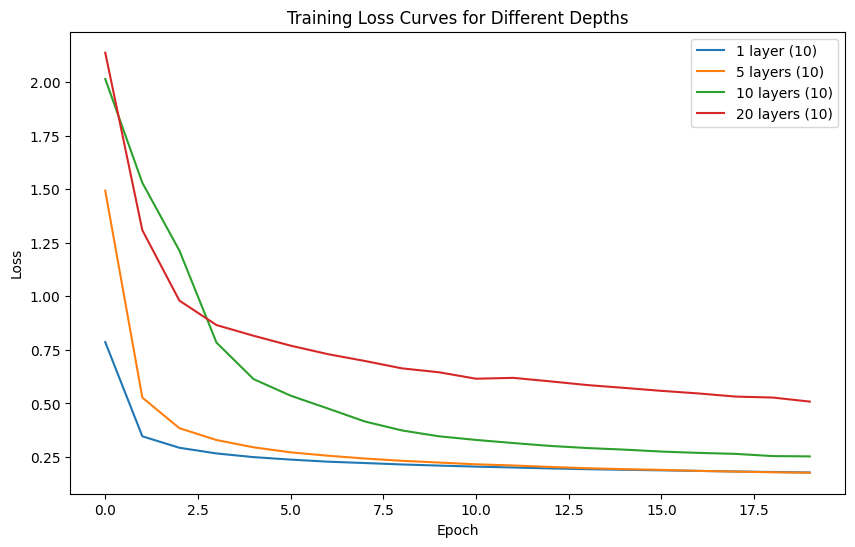

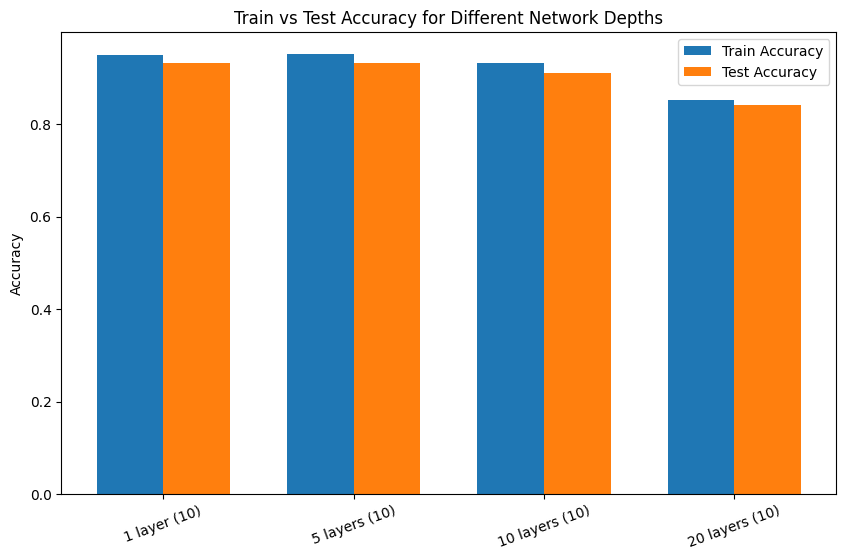

In [ ]:
plt.figure(figsize=(10,6))
for name, curve in loss_curves.items():
    plt.plot(curve, label=name)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves for Different Depths")
plt.legend()
plt.show()

# --- Plot bar chart for training vs test accuracy ---
labels = list(results.keys())
train_accs = [results[k]["train_acc"] for k in labels]
test_accs = [results[k]["test_acc"] for k in labels]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, train_accs, width, label="Train Accuracy")
plt.bar(x + width/2, test_accs, width, label="Test Accuracy")
plt.xticks(x, labels, rotation=20)
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy for Different Network Depths")
plt.legend()
plt.show()


Analyze findings
Observe how increasing depth changes convergence speed, loss behavior, and accuracy.
Relate poor performance in deeper networks to the vanishing/exploding gradient problem.


In [ ]:
print("\nAnalysis:")
print("As network depth increases, training becomes slower, convergence can be unstable, and accuracy may drop.")
print("This is partly due to vanishing/exploding gradient problems in deep MLPs without special techniques like batch norm or residual connections.")


Analysis:
As network depth increases, training becomes slower, convergence can be unstable, and accuracy may drop.
This is partly due to vanishing/exploding gradient problems in deep MLPs without special techniques like batch norm or residual connections.
